In [29]:
import os
import json
import math
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn.functional as F

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.aspect"] = "auto"
plt.rcParams["axes.grid"] = False

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


In [30]:
initial_file = "a_convert_2_nosm.nc"   # <-- change
final_file   = "b_convert_2_nosm.nc"     # <-- change; or set to None

fermi_level_ev = 0.0     # adjust if your corrected data uses a different E_F
ef_window_ev   = 0.05    # near-Fermi window, e.g. 50 meV
wide_window_ev = 0.20    # broader near-E_F window

# How many spectral clusters to form before semantic relabeling
n_clusters = 6

# anomaly threshold in units of MAD-like score
anomaly_quantile = 0.985
boundary_gradient_quantile = 0.92

output_dir = "nanoarpes_state_analysis"
os.makedirs(output_dir, exist_ok=True)

In [31]:
def open_nc_dataset(file_path):
    if file_path is None:
        return None

    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    ds = None
    engines_to_try = [None, "h5netcdf", "netcdf4", "scipy"]

    for eng in engines_to_try:
        try:
            if eng is None:
                ds = xr.open_dataset(file_path)
            else:
                ds = xr.open_dataset(file_path, engine=eng)
            print(f"Opened {file_path} with engine={eng}")
            break
        except Exception as e:
            print(f"Failed opening {file_path} with engine={eng}: {e}")

    if ds is None:
        raise RuntimeError(f"Could not open dataset: {file_path}")

    return ds


def get_main_dataarray(ds):
    candidates = []
    for name, var in ds.data_vars.items():
        try:
            if np.issubdtype(var.dtype, np.number):
                candidates.append((name, int(np.prod(var.shape))))
        except Exception:
            pass

    if not candidates:
        raise ValueError("No numeric data variables found.")

    candidates.sort(key=lambda x: x[1], reverse=True)
    return ds[candidates[0][0]]


ds_init = open_nc_dataset(initial_file)
da_init = get_main_dataarray(ds_init)

if final_file is not None:
    ds_final = open_nc_dataset(final_file)
    da_final = get_main_dataarray(ds_final)
else:
    ds_final = None
    da_final = None

print("Initial dims:", da_init.dims, da_init.shape)
if da_final is not None:
    print("Final dims:", da_final.dims, da_final.shape)

Failed opening a_convert_2_nosm.nc with engine=None: cannot import name '__netcdf4libversion__' from 'netCDF4._netCDF4' (/opt/anaconda3/lib/python3.11/site-packages/netCDF4/_netCDF4.cpython-311-darwin.so)
Opened a_convert_2_nosm.nc with engine=h5netcdf
Failed opening b_convert_2_nosm.nc with engine=None: cannot import name '__netcdf4libversion__' from 'netCDF4._netCDF4' (/opt/anaconda3/lib/python3.11/site-packages/netCDF4/_netCDF4.cpython-311-darwin.so)
Opened b_convert_2_nosm.nc with engine=h5netcdf
Initial dims: ('x', 'y', 'eV', 'phi') (61, 61, 430, 424)
Final dims: ('x', 'y', 'eV', 'phi') (61, 61, 430, 424)


In [32]:
def print_dataset_brief(da):
    print("\nName:", da.name)
    print("Dims:", da.dims)
    print("Shape:", da.shape)
    print("Dtype:", da.dtype)
    print("\nCoordinates:")
    for c in da.coords:
        coord = da.coords[c]
        print(f"  {c}: shape={coord.shape}, dtype={coord.dtype}")
        if coord.ndim == 1 and np.issubdtype(coord.dtype, np.number):
            vals = coord.values
            print(f"      min={vals.min():.6g}, max={vals.max():.6g}")

print_dataset_brief(da_init)
if da_final is not None:
    print_dataset_brief(da_final)


Name: __xarray_dataarray_variable__
Dims: ('x', 'y', 'eV', 'phi')
Shape: (61, 61, 430, 424)
Dtype: int32

Coordinates:
  x: shape=(61,), dtype=float64
      min=1910, max=2090
  y: shape=(61,), dtype=float64
      min=670, max=850
  phi: shape=(424,), dtype=float64
      min=-0.334069, max=0.334069
  eV: shape=(430,), dtype=float64
      min=-1.49707, max=0.517019
  long_z: shape=(), dtype=float64
  short_x: shape=(), dtype=float64
  short_y: shape=(), dtype=float64
  short_z: shape=(), dtype=float64
  theta: shape=(), dtype=float64
  beta: shape=(), dtype=float64
  chi: shape=(), dtype=float64
  hv: shape=(), dtype=float64
  alpha: shape=(), dtype=float64
  psi: shape=(), dtype=float64
  physical_long_x: shape=(), dtype=float64
  physical_long_y: shape=(), dtype=float64
  physical_long_z: shape=(), dtype=float64
  z: shape=(), dtype=float64

Name: __xarray_dataarray_variable__
Dims: ('x', 'y', 'eV', 'phi')
Shape: (61, 61, 430, 424)
Dtype: int32

Coordinates:
  x: shape=(61,), dtype=f

In [33]:
def require_dims(da, required=("x", "y", "eV", "phi")):
    missing = [d for d in required if d not in da.dims]
    if missing:
        raise ValueError(f"Missing required dims: {missing}. Found dims={da.dims}")


def to_float32_numpy(da):
    return np.asarray(da.values, dtype=np.float32)


def get_energy_mask(e_axis, center=0.0, halfwidth=0.05):
    e_axis = np.asarray(e_axis)
    return np.abs(e_axis - center) <= halfwidth


def robust_zscore(arr, axis=0, eps=1e-8):
    med = np.nanmedian(arr, axis=axis, keepdims=True)
    mad = np.nanmedian(np.abs(arr - med), axis=axis, keepdims=True)
    return (arr - med) / (1.4826 * mad + eps)


def safe_divide(a, b, eps=1e-8):
    return a / (b + eps)


def normalize_spectrum(spec, eps=1e-8):
    s = spec.astype(np.float32)
    total = np.sum(s)
    if total <= eps:
        return s
    return s / total


def finite_fill(arr, fill_value=0.0):
    out = np.array(arr, copy=True)
    out[~np.isfinite(out)] = fill_value
    return out

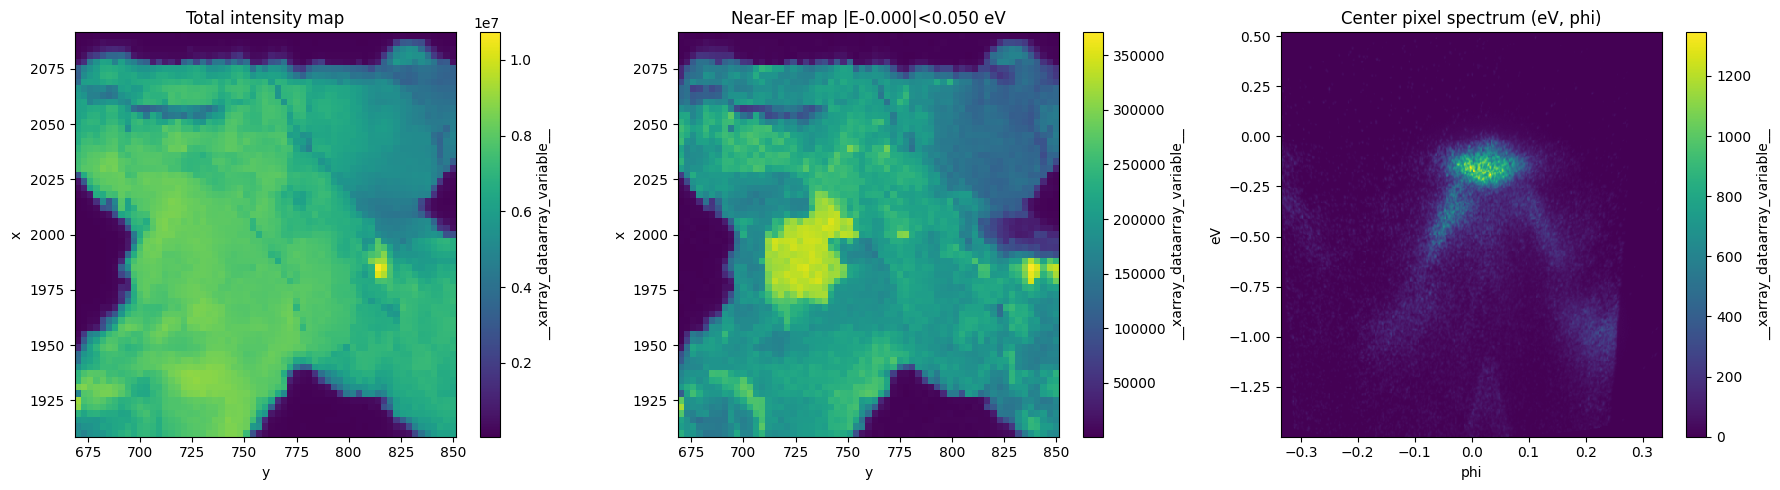

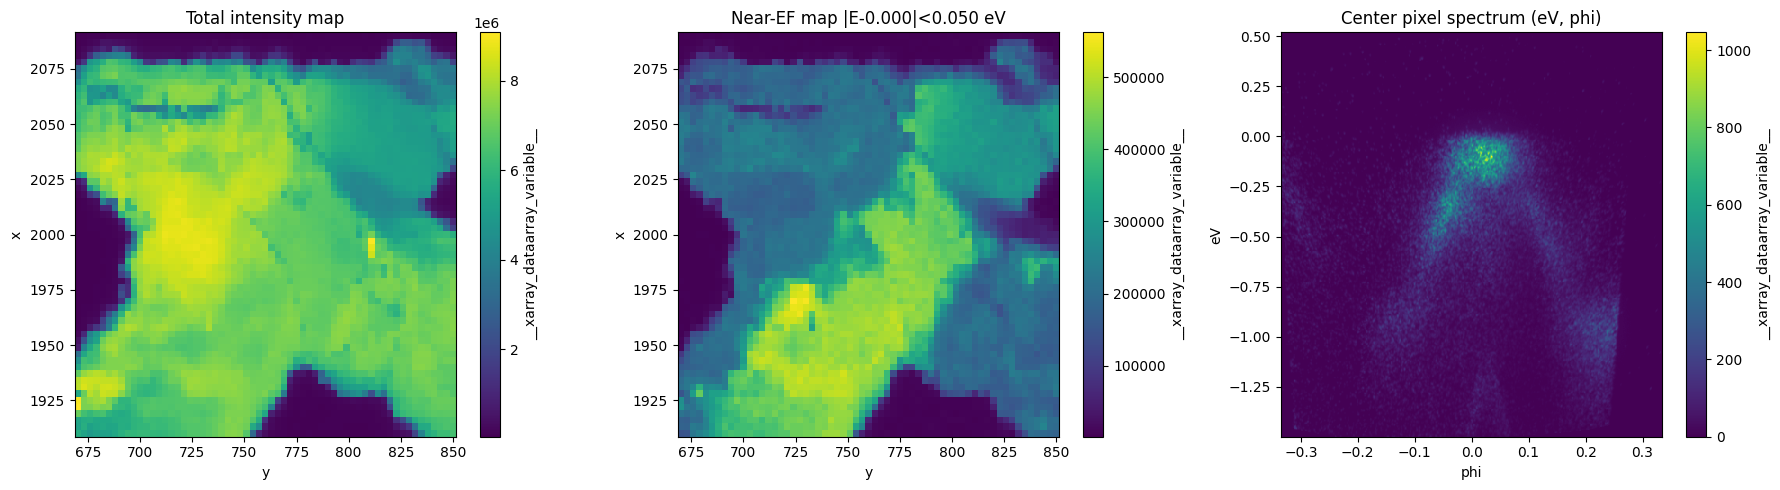

In [34]:
def preview_maps(da, fermi_level=0.0, ef_window=0.05):
    require_dims(da)

    e = da.coords["eV"].values
    ef_mask = get_energy_mask(e, center=fermi_level, halfwidth=ef_window)

    total_map = da.sum(dim=("eV", "phi"))
    ef_map = da.isel(eV=np.where(ef_mask)[0]).sum(dim=("eV", "phi"))

    mid_x = da.sizes["x"] // 2
    mid_y = da.sizes["y"] // 2
    local_spec = da.isel(x=mid_x, y=mid_y)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    total_map.plot(ax=axes[0], cmap="viridis")
    axes[0].set_title("Total intensity map")

    ef_map.plot(ax=axes[1], cmap="viridis")
    axes[1].set_title(f"Near-EF map |E-{fermi_level:.3f}|<{ef_window:.3f} eV")

    local_spec.plot(ax=axes[2], cmap="viridis")
    axes[2].set_title("Center pixel spectrum (eV, phi)")

    plt.tight_layout()
    plt.show()

preview_maps(da_init, fermi_level=fermi_level_ev, ef_window=ef_window_ev)
if da_final is not None:
    preview_maps(da_final, fermi_level=fermi_level_ev, ef_window=ef_window_ev)

In [35]:
def extract_pixel_features(da, fermi_level=0.0, ef_window=0.05, wide_window=0.20):
    require_dims(da)

    data = to_float32_numpy(da)   # shape: (x, y, eV, phi)
    xN, yN, eN, pN = data.shape

    e_axis = np.asarray(da.coords["eV"].values, dtype=np.float32)
    p_axis = np.asarray(da.coords["phi"].values, dtype=np.float32)

    ef_mask = get_energy_mask(e_axis, center=fermi_level, halfwidth=ef_window)
    wide_mask = get_energy_mask(e_axis, center=fermi_level, halfwidth=wide_window)

    X = data.reshape(xN * yN, eN, pN)

    total_intensity = X.sum(axis=(1, 2))

    ef_cube = X[:, ef_mask, :]
    ef_intensity = ef_cube.sum(axis=(1, 2))

    wide_cube = X[:, wide_mask, :]
    wide_intensity = wide_cube.sum(axis=(1, 2))

    ef_fraction = safe_divide(ef_intensity, total_intensity)
    wide_fraction = safe_divide(wide_intensity, total_intensity)

    e_profile = X.sum(axis=2)   # sum over phi => (Npix, eV)
    p_profile = X.sum(axis=1)   # sum over eV => (Npix, phi)

    e_profile_norm = np.array([normalize_spectrum(v) for v in e_profile], dtype=np.float32)
    p_profile_norm = np.array([normalize_spectrum(v) for v in p_profile], dtype=np.float32)

    e_centroid = (e_profile_norm * e_axis[None, :]).sum(axis=1)
    e_var = (e_profile_norm * (e_axis[None, :] - e_centroid[:, None])**2).sum(axis=1)

    p_centroid = (p_profile_norm * p_axis[None, :]).sum(axis=1)
    p_var = (p_profile_norm * (p_axis[None, :] - p_centroid[:, None])**2).sum(axis=1)

    p_mid = len(p_axis) // 2
    left_intensity = p_profile[:, :p_mid].sum(axis=1)
    right_intensity = p_profile[:, p_mid:].sum(axis=1)
    phi_asymmetry = safe_divide(right_intensity - left_intensity, right_intensity + left_intensity)

    # spectral entropy on full normalized spectrum
    X_flat = X.reshape(xN * yN, -1)
    X_norm = np.array([normalize_spectrum(v) for v in X_flat], dtype=np.float32)
    spectral_entropy = -np.sum(X_norm * np.log(X_norm + 1e-12), axis=1)

    # sharpness: maximum / mean
    spectral_max = X_flat.max(axis=1)
    spectral_mean = X_flat.mean(axis=1)
    spectral_sharpness = safe_divide(spectral_max, spectral_mean)

    # spatial maps for local spatial features
    ef_map = ef_intensity.reshape(xN, yN)
    total_map = total_intensity.reshape(xN, yN)

    gx, gy = np.gradient(ef_map)
    grad_mag = np.sqrt(gx**2 + gy**2)

    # local neighbor difference
    neighbor_diff = np.zeros_like(ef_map, dtype=np.float32)
    for i in range(xN):
        for j in range(yN):
            vals = []
            c = ef_map[i, j]
            for di, dj in [(-1,0),(1,0),(0,-1),(0,1)]:
                ii, jj = i + di, j + dj
                if 0 <= ii < xN and 0 <= jj < yN:
                    vals.append(abs(c - ef_map[ii, jj]))
            neighbor_diff[i, j] = np.mean(vals) if len(vals) > 0 else 0.0

    # local 3x3 contrast
    local_contrast = np.zeros_like(ef_map, dtype=np.float32)
    pad = np.pad(ef_map, 1, mode="reflect")
    for i in range(xN):
        for j in range(yN):
            patch = pad[i:i+3, j:j+3]
            local_contrast[i, j] = patch.std()

    features = {
        "total_intensity": total_intensity.reshape(xN, yN),
        "ef_intensity": ef_intensity.reshape(xN, yN),
        "wide_intensity": wide_intensity.reshape(xN, yN),
        "ef_fraction": ef_fraction.reshape(xN, yN),
        "wide_fraction": wide_fraction.reshape(xN, yN),
        "e_centroid": e_centroid.reshape(xN, yN),
        "e_var": e_var.reshape(xN, yN),
        "phi_centroid": p_centroid.reshape(xN, yN),
        "phi_var": p_var.reshape(xN, yN),
        "phi_asymmetry": phi_asymmetry.reshape(xN, yN),
        "spectral_entropy": spectral_entropy.reshape(xN, yN),
        "spectral_sharpness": spectral_sharpness.reshape(xN, yN),
        "ef_grad_mag": grad_mag,
        "ef_neighbor_diff": neighbor_diff,
        "ef_local_contrast": local_contrast,
    }

    # main feature matrix for clustering
    feat_names = [
        "total_intensity",
        "ef_intensity",
        "wide_intensity",
        "ef_fraction",
        "wide_fraction",
        "e_centroid",
        "e_var",
        "phi_centroid",
        "phi_var",
        "phi_asymmetry",
        "spectral_entropy",
        "spectral_sharpness",
        "ef_grad_mag",
        "ef_neighbor_diff",
        "ef_local_contrast",
    ]

    Fmat = np.stack([features[k].reshape(-1) for k in feat_names], axis=1).astype(np.float32)
    Fmat = finite_fill(Fmat, fill_value=0.0)

    return features, feat_names, Fmat

In [36]:
features_init, feat_names, F_init = extract_pixel_features(
    da_init,
    fermi_level=fermi_level_ev,
    ef_window=ef_window_ev,
    wide_window=wide_window_ev
)

if da_final is not None:
    features_final, _, F_final = extract_pixel_features(
        da_final,
        fermi_level=fermi_level_ev,
        ef_window=ef_window_ev,
        wide_window=wide_window_ev
    )
else:
    features_final, F_final = None, None

print("Feature names:")
for i, name in enumerate(feat_names):
    print(i, name)

print("F_init shape:", F_init.shape)
if F_final is not None:
    print("F_final shape:", F_final.shape)

Feature names:
0 total_intensity
1 ef_intensity
2 wide_intensity
3 ef_fraction
4 wide_fraction
5 e_centroid
6 e_var
7 phi_centroid
8 phi_var
9 phi_asymmetry
10 spectral_entropy
11 spectral_sharpness
12 ef_grad_mag
13 ef_neighbor_diff
14 ef_local_contrast
F_init shape: (3721, 15)
F_final shape: (3721, 15)


In [37]:
def build_joint_feature_matrix(F_init, F_final=None):
    # robustly standardize initial and final together if both exist
    if F_final is None:
        Z = robust_zscore(F_init, axis=0)
        return finite_fill(Z, 0.0), ["single_state_only"]

    joint = np.concatenate([F_init, F_final], axis=0)
    joint_z = robust_zscore(joint, axis=0)
    joint_z = finite_fill(joint_z, 0.0)

    N = F_init.shape[0]
    Z_init = joint_z[:N]
    Z_final = joint_z[N:]

    delta = Z_final - Z_init
    ratio_like = np.sign(Z_final) * np.sqrt(np.abs(Z_final - Z_init) + 1e-8)

    joint_features = np.concatenate([Z_init, Z_final, delta, ratio_like], axis=1)
    return finite_fill(joint_features, 0.0), ["initial_final_joint"]

joint_features, mode_info = build_joint_feature_matrix(F_init, F_final)
print("joint_features shape:", joint_features.shape)

joint_features shape: (3721, 60)


In [38]:
def torch_pca(X_np, n_components=8):
    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    mean = X.mean(dim=0, keepdim=True)
    Xc = X - mean

    # SVD
    U, S, Vh = torch.linalg.svd(Xc, full_matrices=False)
    comps = Vh[:n_components]
    scores = Xc @ comps.T

    explained = (S**2) / (X.shape[0] - 1)
    explained_ratio = explained / explained.sum()

    return {
        "scores": scores.detach().cpu().numpy(),
        "components": comps.detach().cpu().numpy(),
        "mean": mean.detach().cpu().numpy(),
        "explained_ratio": explained_ratio[:n_components].detach().cpu().numpy()
    }

pca_out = torch_pca(joint_features, n_components=8)
X_embed = pca_out["scores"]

print("PCA explained variance ratio:")
print(pca_out["explained_ratio"])

PCA explained variance ratio:
[0.55523    0.11753646 0.07986719 0.0693597  0.0461301  0.03335476
 0.02410736 0.01924767]


In [39]:
def torch_kmeans(X_np, k=6, n_iter=100, n_init=10, seed=0):
    torch.manual_seed(seed)
    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    N, D = X.shape

    best_inertia = None
    best_labels = None
    best_centroids = None

    for init_idx in range(n_init):
        perm = torch.randperm(N, device=device)
        centroids = X[perm[:k]].clone()

        for _ in range(n_iter):
            dists = torch.cdist(X, centroids)  # (N, k)
            labels = torch.argmin(dists, dim=1)

            new_centroids = []
            for c in range(k):
                mask = labels == c
                if mask.sum() == 0:
                    new_centroids.append(X[torch.randint(0, N, (1,), device=device)].squeeze(0))
                else:
                    new_centroids.append(X[mask].mean(dim=0))
            new_centroids = torch.stack(new_centroids, dim=0)

            if torch.allclose(new_centroids, centroids, atol=1e-5):
                centroids = new_centroids
                break

            centroids = new_centroids

        dists = torch.cdist(X, centroids)
        final_labels = torch.argmin(dists, dim=1)
        inertia = torch.sum((X - centroids[final_labels])**2).item()

        if (best_inertia is None) or (inertia < best_inertia):
            best_inertia = inertia
            best_labels = final_labels.detach().cpu().numpy()
            best_centroids = centroids.detach().cpu().numpy()

    return best_labels, best_centroids, best_inertia


cluster_labels, cluster_centroids, inertia = torch_kmeans(
    X_embed,
    k=n_clusters,
    n_iter=100,
    n_init=20,
    seed=42
)

print("K-means inertia:", inertia)

K-means inertia: 240329.421875


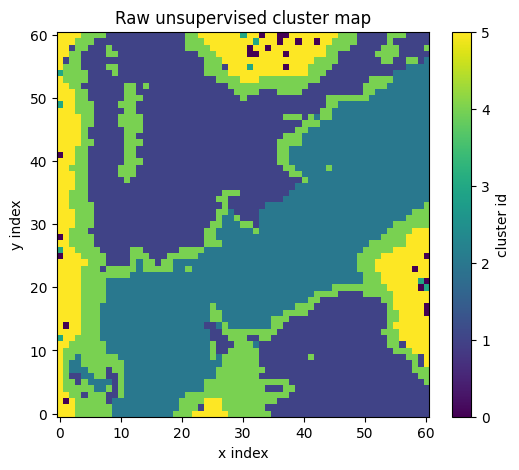

In [40]:
xN = da_init.sizes["x"]
yN = da_init.sizes["y"]

cluster_map = cluster_labels.reshape(xN, yN)

plt.figure(figsize=(6, 5))
plt.imshow(cluster_map.T, origin="lower", interpolation="nearest")
plt.colorbar(label="cluster id")
plt.title("Raw unsupervised cluster map")
plt.xlabel("x index")
plt.ylabel("y index")
plt.show()

In [41]:
def summarize_clusters(cluster_map, features_init, features_final=None):
    labels = np.unique(cluster_map)
    summary = {}

    for c in labels:
        mask = cluster_map == c
        entry = {"count": int(mask.sum())}

        for name, fmap in features_init.items():
            entry[f"init_{name}_mean"] = float(np.mean(fmap[mask]))
            entry[f"init_{name}_median"] = float(np.median(fmap[mask]))

        if features_final is not None:
            for name, fmap in features_final.items():
                entry[f"final_{name}_mean"] = float(np.mean(fmap[mask]))
                entry[f"final_{name}_median"] = float(np.median(fmap[mask]))
                entry[f"delta_{name}_mean"] = float(np.mean(fmap[mask] - features_init[name][mask]))
                entry[f"delta_{name}_median"] = float(np.median(fmap[mask] - features_init[name][mask]))

        summary[int(c)] = entry

    return summary


cluster_summary = summarize_clusters(cluster_map, features_init, features_final)

with open(os.path.join(output_dir, "cluster_summary.json"), "w") as f:
    json.dump(cluster_summary, f, indent=2)

cluster_summary

{0: {'count': 23,
  'init_total_intensity_mean': 80753.1328125,
  'init_total_intensity_median': 75572.0,
  'init_ef_intensity_mean': 2711.78271484375,
  'init_ef_intensity_median': 2643.0,
  'init_wide_intensity_mean': 20685.26171875,
  'init_wide_intensity_median': 19951.0,
  'init_ef_fraction_mean': 0.03381086513400078,
  'init_ef_fraction_median': 0.03333196043968201,
  'init_wide_fraction_mean': 0.2561633884906769,
  'init_wide_fraction_median': 0.25637087225914,
  'init_e_centroid_mean': -0.45557329058647156,
  'init_e_centroid_median': -0.4520283341407776,
  'init_e_var_mean': 0.18421374261379242,
  'init_e_var_median': 0.183557391166687,
  'init_phi_centroid_mean': -0.03463498130440712,
  'init_phi_centroid_median': -0.034842632710933685,
  'init_phi_var_mean': 0.01890328899025917,
  'init_phi_var_median': 0.018391087651252747,
  'init_phi_asymmetry_mean': -0.18503330647945404,
  'init_phi_asymmetry_median': -0.19132690131664276,
  'init_spectral_entropy_mean': 8.95680809020996

In [42]:
def compute_pixel_anomaly_score(X_embed, labels, centroids):
    X = np.asarray(X_embed, dtype=np.float32)
    C = np.asarray(centroids, dtype=np.float32)
    d = np.sqrt(((X - C[labels])**2).sum(axis=1))
    return d


def assign_semantic_labels(cluster_map, cluster_summary, features_init, features_final=None,
                           X_embed=None, cluster_labels=None, cluster_centroids=None,
                           anomaly_quantile=0.985, boundary_gradient_quantile=0.92):

    xN, yN = cluster_map.shape
    raw_to_name = {}

    # cluster-level statistics used for ranking
    clusters = sorted(cluster_summary.keys())

    init_ef = {c: cluster_summary[c]["init_ef_fraction_mean"] for c in clusters}
    init_wide = {c: cluster_summary[c]["init_wide_fraction_mean"] for c in clusters}
    init_entropy = {c: cluster_summary[c]["init_spectral_entropy_mean"] for c in clusters}
    init_sharp = {c: cluster_summary[c]["init_spectral_sharpness_mean"] for c in clusters}
    init_phi_asym = {c: cluster_summary[c]["init_phi_asymmetry_mean"] for c in clusters}
    init_evar = {c: cluster_summary[c]["init_e_var_mean"] for c in clusters}

    if features_final is not None:
        delta_ef = {c: cluster_summary[c]["delta_ef_fraction_mean"] for c in clusters}
    else:
        delta_ef = {c: 0.0 for c in clusters}

    # rank clusters by metallicity proxy
    metallic_score = {
        c: 2.0 * init_ef[c] + 1.0 * init_wide[c] + 0.25 * init_sharp[c] - 0.15 * init_entropy[c]
        for c in clusters
    }
    ranked = sorted(clusters, key=lambda c: metallic_score[c])

    # base assignments
    if len(ranked) >= 1:
        raw_to_name[ranked[0]] = "insulating"
    if len(ranked) >= 2:
        raw_to_name[ranked[1]] = "intermediate"
    if len(ranked) >= 3:
        raw_to_name[ranked[-1]] = "metallic"

    # identify metallic-like leftovers for metastable A/B
    remaining = [c for c in clusters if c not in raw_to_name]
    metallic_like = sorted(remaining, key=lambda c: metallic_score[c], reverse=True)

    if len(metallic_like) >= 1:
        raw_to_name[metallic_like[0]] = "metastable metallic type A"
    if len(metallic_like) >= 2:
        raw_to_name[metallic_like[1]] = "metastable metallic type B"

    # any still unassigned => intermediate
    for c in clusters:
        if c not in raw_to_name:
            raw_to_name[c] = "intermediate"

    # if final exists, detect cluster with strongest metallicity loss
    if features_final is not None:
        revert_candidate = min(clusters, key=lambda c: delta_ef[c])  # biggest loss in EF weight
        # overwrite only if it is substantially decreasing
        if delta_ef[revert_candidate] < np.percentile(list(delta_ef.values()), 20):
            raw_to_name[revert_candidate] = "erased / reverted"

    # pixel-level anomaly / boundary mask
    boundary_base = features_init["ef_grad_mag"] + features_init["ef_local_contrast"] + features_init["ef_neighbor_diff"]
    bth = np.quantile(boundary_base.reshape(-1), boundary_gradient_quantile)
    boundary_mask = boundary_base >= bth

    anomaly_mask = np.zeros((xN, yN), dtype=bool)
    if X_embed is not None and cluster_labels is not None and cluster_centroids is not None:
        anomaly_score = compute_pixel_anomaly_score(X_embed, cluster_labels, cluster_centroids).reshape(xN, yN)
        ath = np.quantile(anomaly_score.reshape(-1), anomaly_quantile)
        anomaly_mask = anomaly_score >= ath
    else:
        anomaly_score = np.zeros((xN, yN), dtype=np.float32)

    semantic_map = np.empty((xN, yN), dtype=object)
    for i in range(xN):
        for j in range(yN):
            semantic_map[i, j] = raw_to_name[int(cluster_map[i, j])]

    # overwrite anomalous/boundary pixels last
    special_mask = boundary_mask | anomaly_mask
    semantic_map[special_mask] = "boundary-like / anomalous"

    return {
        "raw_to_name": raw_to_name,
        "semantic_map": semantic_map,
        "boundary_mask": boundary_mask,
        "anomaly_mask": anomaly_mask,
        "anomaly_score": anomaly_score,
        "boundary_score": boundary_base,
    }


semantic_out = assign_semantic_labels(
    cluster_map=cluster_map,
    cluster_summary=cluster_summary,
    features_init=features_init,
    features_final=features_final,
    X_embed=X_embed,
    cluster_labels=cluster_labels,
    cluster_centroids=cluster_centroids,
    anomaly_quantile=anomaly_quantile,
    boundary_gradient_quantile=boundary_gradient_quantile
)

semantic_map = semantic_out["semantic_map"]
raw_to_name = semantic_out["raw_to_name"]

print("Cluster -> semantic label mapping")
for k, v in raw_to_name.items():
    print(k, "->", v)

Cluster -> semantic label mapping
4 -> insulating
2 -> intermediate
3 -> metallic
0 -> metastable metallic type A
5 -> metastable metallic type B
1 -> erased / reverted


In [43]:
state_names = [
    "insulating",
    "metallic",
    "intermediate",
    "metastable metallic type A",
    "metastable metallic type B",
    "erased / reverted",
    "boundary-like / anomalous",
]

state_to_code = {name: i for i, name in enumerate(state_names)}
code_to_state = {i: name for name, i in state_to_code.items()}

semantic_code_map = np.vectorize(lambda s: state_to_code[s])(semantic_map)

print(state_to_code)

{'insulating': 0, 'metallic': 1, 'intermediate': 2, 'metastable metallic type A': 3, 'metastable metallic type B': 4, 'erased / reverted': 5, 'boundary-like / anomalous': 6}


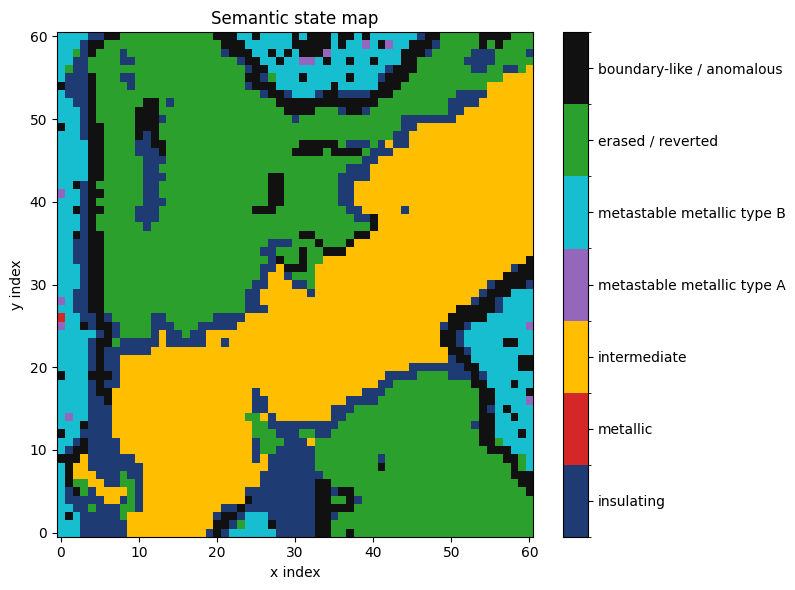

In [44]:
state_colors = {
    "insulating": "#1f3b73",
    "metallic": "#d62728",
    "intermediate": "#ffbf00",
    "metastable metallic type A": "#9467bd",
    "metastable metallic type B": "#17becf",
    "erased / reverted": "#2ca02c",
    "boundary-like / anomalous": "#111111",
}

cmap = mcolors.ListedColormap([state_colors[s] for s in state_names])
norm = mcolors.BoundaryNorm(np.arange(-0.5, len(state_names)+0.5, 1), cmap.N)

plt.figure(figsize=(8, 6))
plt.imshow(semantic_code_map.T, origin="lower", cmap=cmap, norm=norm, interpolation="nearest")
cbar = plt.colorbar(ticks=np.arange(len(state_names)))
cbar.ax.set_yticklabels(state_names)
plt.title("Semantic state map")
plt.xlabel("x index")
plt.ylabel("y index")
plt.tight_layout()
plt.show()

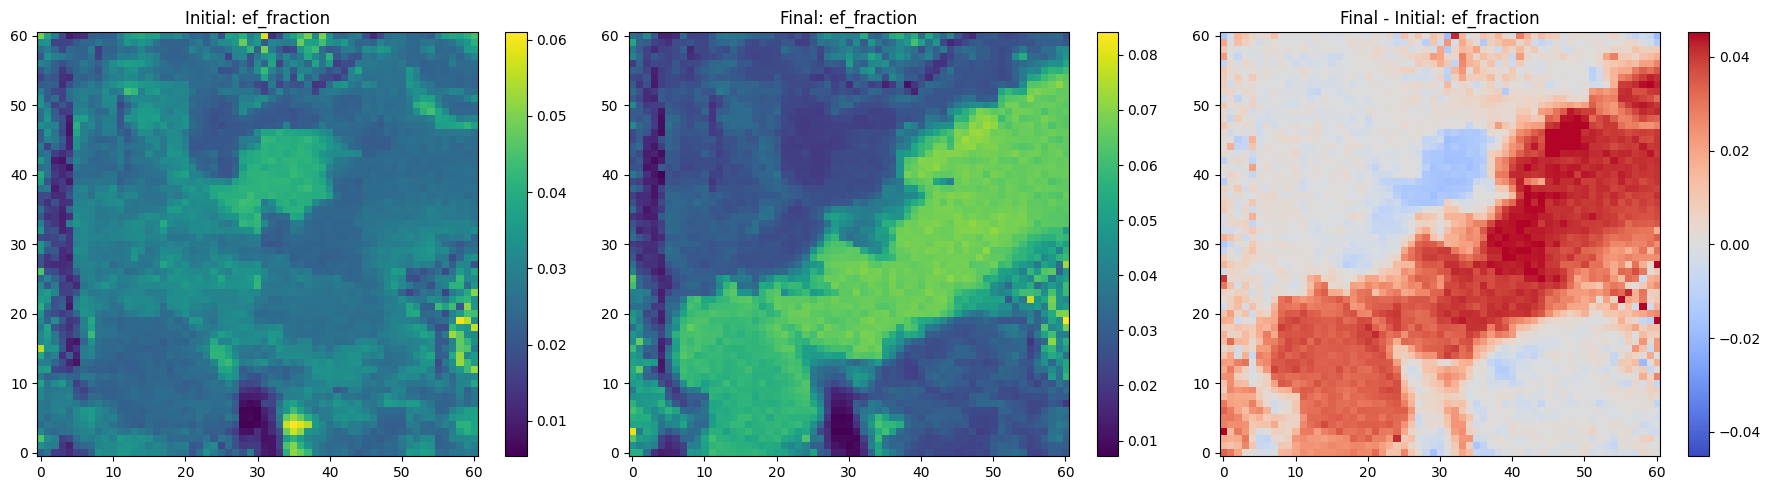

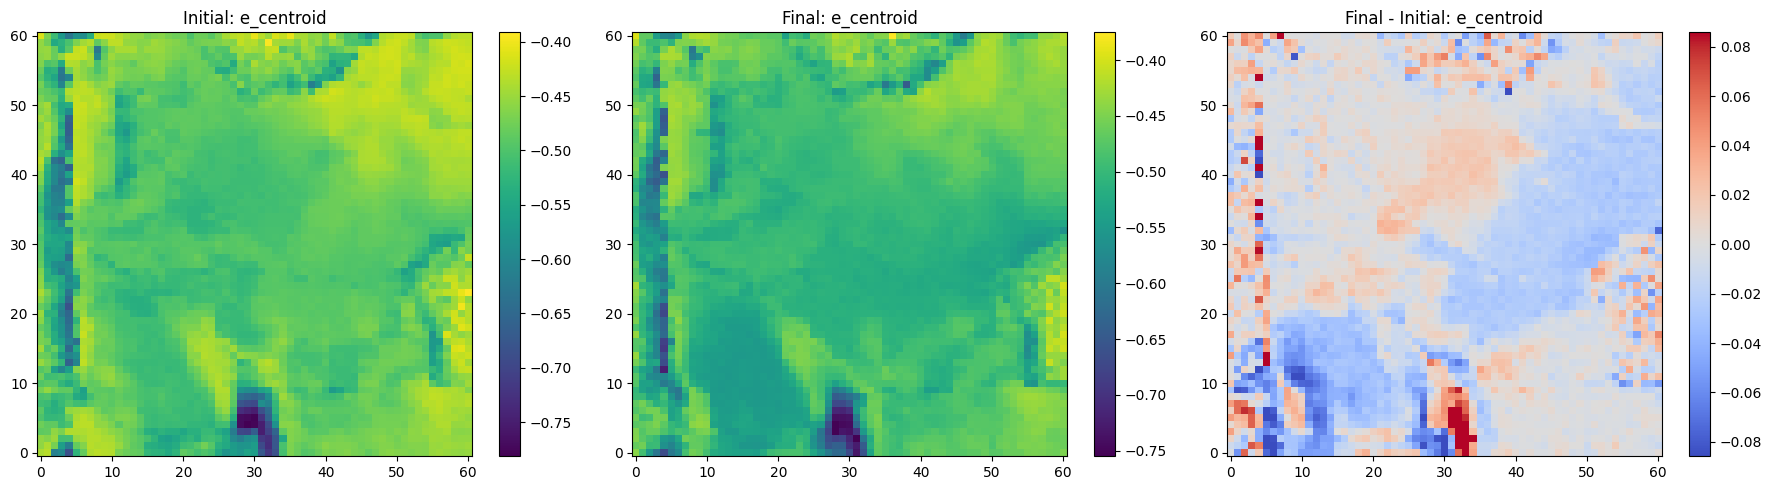

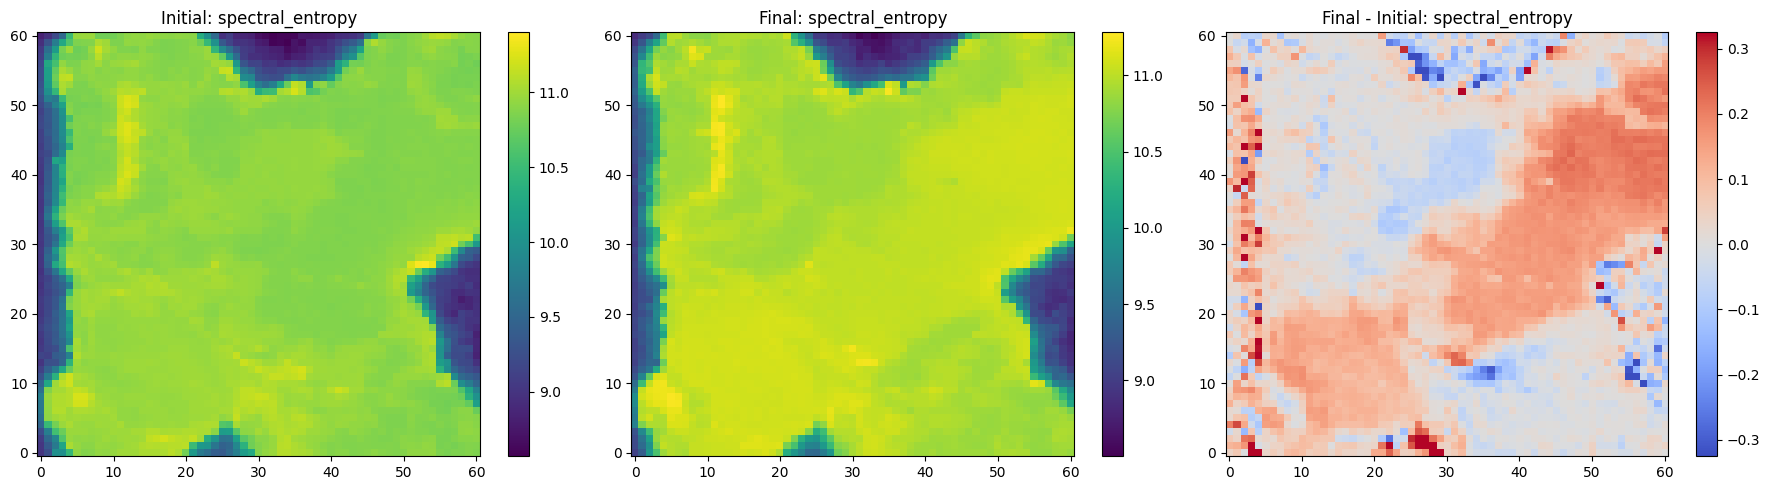

In [45]:
def show_feature_comparison(features_init, features_final, feature_name):
    if features_final is None:
        raise ValueError("No final dataset loaded.")

    A = features_init[feature_name]
    B = features_final[feature_name]
    D = B - A

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    im0 = axes[0].imshow(A.T, origin="lower", cmap="viridis")
    axes[0].set_title(f"Initial: {feature_name}")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(B.T, origin="lower", cmap="viridis")
    axes[1].set_title(f"Final: {feature_name}")
    plt.colorbar(im1, ax=axes[1])

    vmax = np.nanpercentile(np.abs(D), 99)
    im2 = axes[2].imshow(D.T, origin="lower", cmap="coolwarm", vmin=-vmax, vmax=vmax)
    axes[2].set_title(f"Final - Initial: {feature_name}")
    plt.colorbar(im2, ax=axes[2])

    plt.tight_layout()
    plt.show()

if features_final is not None:
    show_feature_comparison(features_init, features_final, "ef_fraction")
    show_feature_comparison(features_init, features_final, "e_centroid")
    show_feature_comparison(features_init, features_final, "spectral_entropy")

In [46]:
def simple_state_from_features(ef_fraction, q_ins=None, q_met=None):
    vals = ef_fraction.reshape(-1)
    if q_ins is None:
        q_ins = np.quantile(vals, 0.30)
    if q_met is None:
        q_met = np.quantile(vals, 0.70)

    state = np.empty_like(ef_fraction, dtype=object)
    state[:] = "intermediate"
    state[ef_fraction <= q_ins] = "insulating"
    state[ef_fraction >= q_met] = "metallic"
    return state, q_ins, q_met


if features_final is not None:
    init_simple, q_ins, q_met = simple_state_from_features(features_init["ef_fraction"])
    final_simple, _, _ = simple_state_from_features(features_final["ef_fraction"], q_ins=q_ins, q_met=q_met)

    transition_map = np.empty(init_simple.shape, dtype=object)
    for i in range(init_simple.shape[0]):
        for j in range(init_simple.shape[1]):
            transition_map[i, j] = f"{init_simple[i,j]} -> {final_simple[i,j]}"

    unique_transitions = sorted(set(transition_map.reshape(-1).tolist()))
    print("Unique transitions:")
    for t in unique_transitions:
        print(" ", t)

Unique transitions:
  insulating -> insulating
  insulating -> intermediate
  insulating -> metallic
  intermediate -> insulating
  intermediate -> intermediate
  intermediate -> metallic
  metallic -> insulating
  metallic -> intermediate
  metallic -> metallic


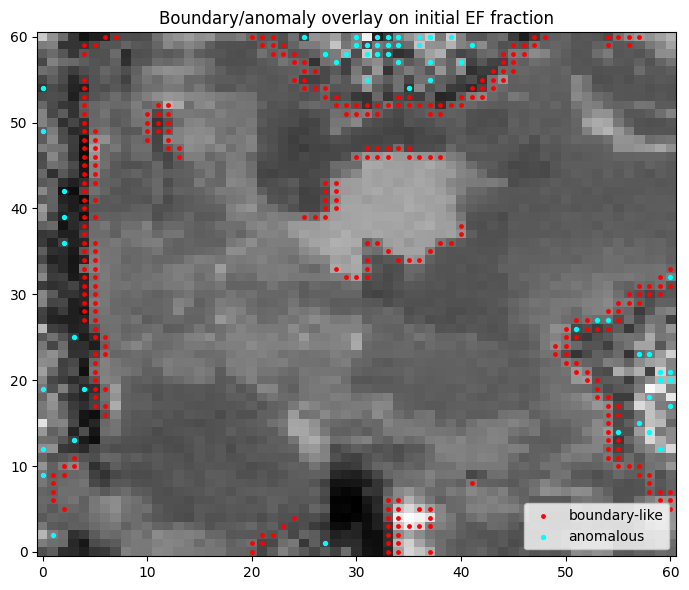

In [47]:
def overlay_boundary_on_map(base_map, boundary_mask, anomaly_mask=None, title=""):
    plt.figure(figsize=(7, 6))
    plt.imshow(base_map.T, origin="lower", cmap="gray")
    yy, xx = np.where(boundary_mask.T)
    plt.scatter(xx, yy, s=6, c="red", label="boundary-like")
    if anomaly_mask is not None:
        yy2, xx2 = np.where(anomaly_mask.T)
        plt.scatter(xx2, yy2, s=8, c="cyan", label="anomalous")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

overlay_boundary_on_map(
    features_init["ef_fraction"],
    semantic_out["boundary_mask"],
    semantic_out["anomaly_mask"],
    title="Boundary/anomaly overlay on initial EF fraction"
)

In [48]:
np.save(os.path.join(output_dir, "cluster_map.npy"), cluster_map)
np.save(os.path.join(output_dir, "semantic_code_map.npy"), semantic_code_map)
np.save(os.path.join(output_dir, "boundary_mask.npy"), semantic_out["boundary_mask"])
np.save(os.path.join(output_dir, "anomaly_mask.npy"), semantic_out["anomaly_mask"])
np.save(os.path.join(output_dir, "anomaly_score.npy"), semantic_out["anomaly_score"])
np.save(os.path.join(output_dir, "boundary_score.npy"), semantic_out["boundary_score"])

with open(os.path.join(output_dir, "state_to_code.json"), "w") as f:
    json.dump(state_to_code, f, indent=2)

with open(os.path.join(output_dir, "raw_cluster_to_semantic_label.json"), "w") as f:
    json.dump({str(k): v for k, v in raw_to_name.items()}, f, indent=2)

print("Saved outputs to:", output_dir)

Saved outputs to: nanoarpes_state_analysis



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/opt/anaconda3/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/opt/anaconda3/lib/python3.11/runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "/opt/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.11/sit

AttributeError: _ARRAY_API not found

Failed opening a_convert_2_nosm.nc with engine=None: execution of module netCDF4._netCDF4 raised unreported exception
Opened a_convert_2_nosm.nc with engine=h5netcdf
Failed opening b_convert_2_nosm.nc with engine=None: cannot import name '__netcdf4libversion__' from 'netCDF4._netCDF4' (/opt/anaconda3/lib/python3.11/site-packages/netCDF4/_netCDF4.cpython-311-darwin.so)
Opened b_convert_2_nosm.nc with engine=h5netcdf
Failed opening c_convert_2_nosm.nc with engine=None: cannot import name '__netcdf4libversion__' from 'netCDF4._netCDF4' (/opt/anaconda3/lib/python3.11/site-packages/netCDF4/_netCDF4.cpython-311-darwin.so)
Opened c_convert_2_nosm.nc with engine=h5netcdf
Failed opening d_convert_2_nosm.nc with engine=None: cannot import name '__netcdf4libversion__' from 'netCDF4._netCDF4' (/opt/anaconda3/lib/python3.11/site-packages/netCDF4/_netCDF4.cpython-311-darwin.so)
Opened d_convert_2_nosm.nc with engine=h5netcdf


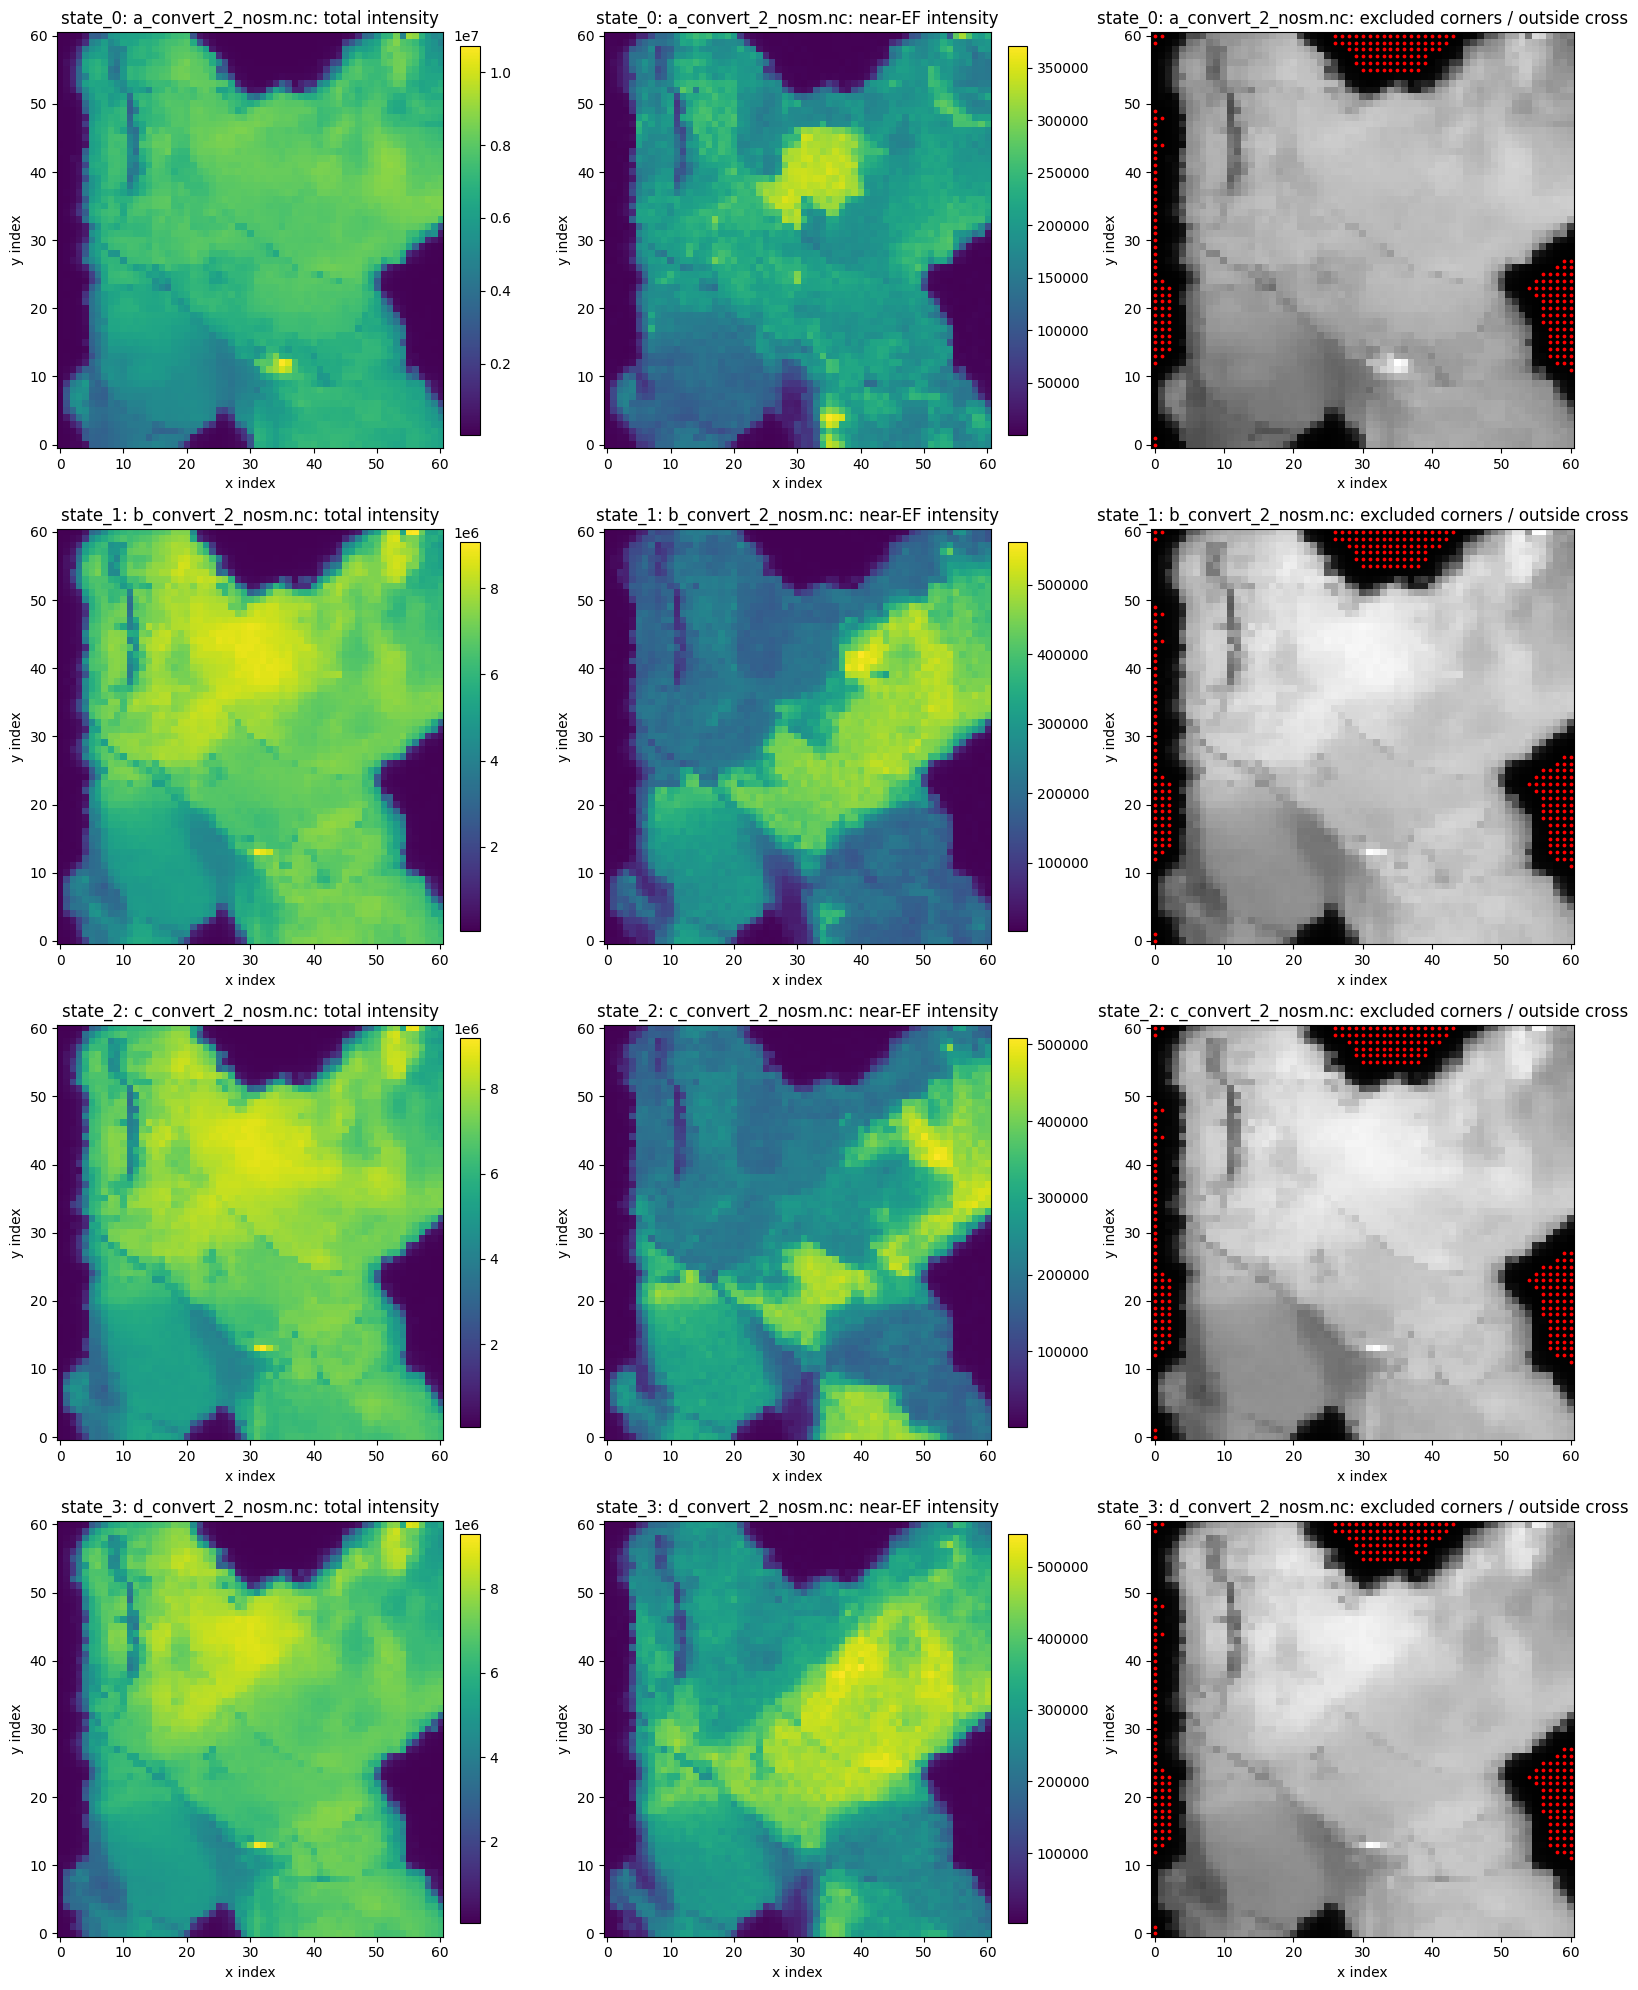

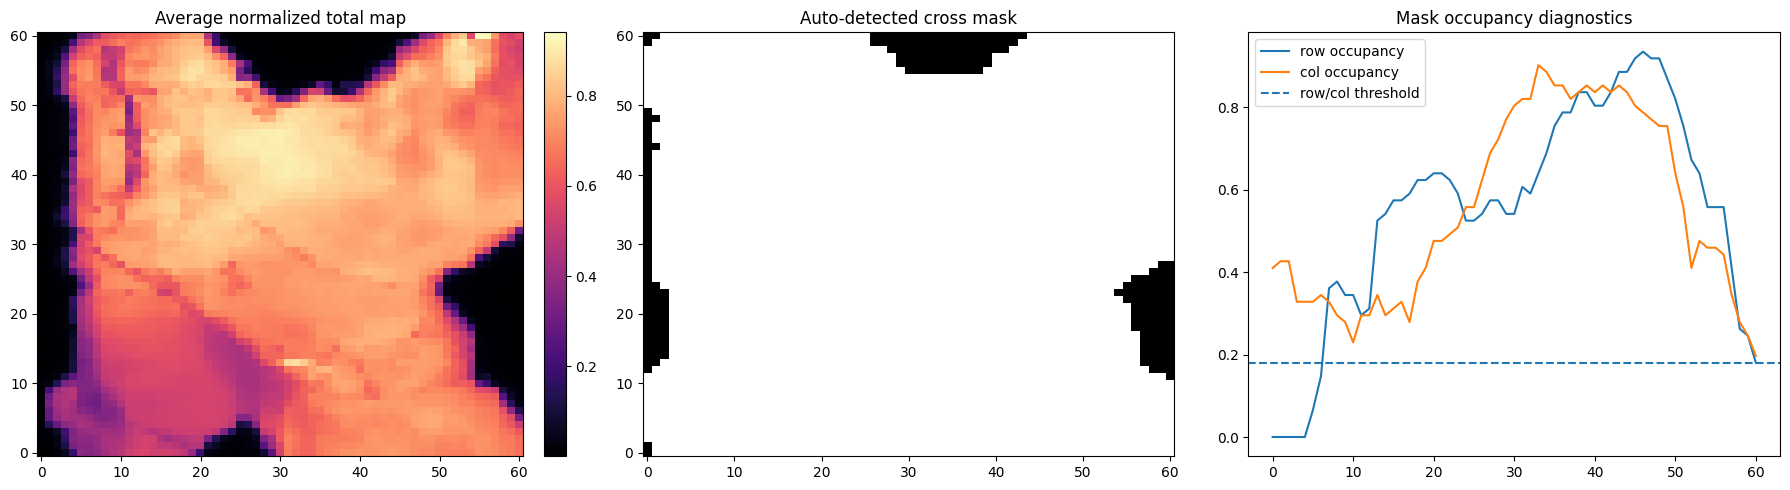

Loaded files in this sequence order:
  0: state_0: a_convert_2_nosm.nc -> a_convert_2_nosm.nc
  1: state_1: b_convert_2_nosm.nc -> b_convert_2_nosm.nc
  2: state_2: c_convert_2_nosm.nc -> c_convert_2_nosm.nc
  3: state_3: d_convert_2_nosm.nc -> d_convert_2_nosm.nc

Mask stats:
  valid pixels inside cross: 3501
  excluded pixels: 220


In [9]:
# =========================
# CELL 1: load + preview (no widgets)
# =========================

import os
import sys
import tempfile
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.aspect"] = "auto"
plt.rcParams["axes.grid"] = False

# -------------------------
# User-adjustable inputs
# -------------------------

# OPTION A:
# Put your .nc file paths here in the exact sequence order.
# Example:
# nc_file_paths = [
#     "/path/to/state0.nc",
#     "/path/to/state1.nc",
#     "/path/to/state2.nc",
#     "/path/to/state3.nc",
# ]
nc_file_paths = [
    "a_convert_2_nosm.nc",
    "b_convert_2_nosm.nc",
    "c_convert_2_nosm.nc",
    "d_convert_2_nosm.nc",
]

# OPTION B:
# If you are in Google Colab, set this to True to upload files interactively.
use_colab_upload = False

fermi_level_ev = 0.0
ef_window_ev = 0.05

# Cross-mask controls
cross_threshold_quantile = 0.45
cross_row_fraction = 0.18
cross_col_fraction = 0.18
cross_background_quantile = 0.10
cross_pad = 1

# -------------------------
# Globals for Cell 2
# -------------------------
UPLOADED_NC_FILES = []
UPLOADED_STATE_NAMES = []
UPLOADED_DATASETS = []
UPLOADED_DATAARRAYS = []

# -------------------------
# Helpers
# -------------------------
def open_nc_dataset(file_path):
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    ds = None
    engines_to_try = [None, "h5netcdf", "netcdf4", "scipy"]
    for eng in engines_to_try:
        try:
            if eng is None:
                ds = xr.open_dataset(file_path)
            else:
                ds = xr.open_dataset(file_path, engine=eng)
            print(f"Opened {os.path.basename(file_path)} with engine={eng}")
            break
        except Exception as e:
            print(f"Failed opening {os.path.basename(file_path)} with engine={eng}: {e}")

    if ds is None:
        raise RuntimeError(f"Could not open dataset: {file_path}")
    return ds

def get_main_dataarray(ds):
    candidates = []
    for name, var in ds.data_vars.items():
        try:
            if np.issubdtype(var.dtype, np.number):
                candidates.append((name, int(np.prod(var.shape))))
        except Exception:
            pass
    if not candidates:
        raise ValueError("No numeric data variables found.")
    candidates.sort(key=lambda x: x[1], reverse=True)
    return ds[candidates[0][0]]

def require_dims(da, required=("x", "y", "eV", "phi")):
    missing = [d for d in required if d not in da.dims]
    if missing:
        raise ValueError(f"Missing required dims: {missing}. Found dims={da.dims}")

def get_energy_mask(e_axis, center=0.0, halfwidth=0.05):
    e_axis = np.asarray(e_axis)
    return np.abs(e_axis - center) <= halfwidth

def total_and_ef_maps(da, fermi_level=0.0, ef_window=0.05):
    require_dims(da)
    e = np.asarray(da.coords["eV"].values, dtype=np.float32)
    ef_mask = get_energy_mask(e, center=fermi_level, halfwidth=ef_window)
    total_map = da.sum(dim=("eV", "phi")).values.astype(np.float32)
    ef_map = da.isel(eV=np.where(ef_mask)[0]).sum(dim=("eV", "phi")).values.astype(np.float32)
    return total_map, ef_map

def dilate_mask(mask, n_iter=1):
    out = mask.copy()
    for _ in range(max(0, int(n_iter))):
        padded = np.pad(out, 1, mode="edge")
        new_mask = np.zeros_like(out, dtype=bool)
        for di in (-1, 0, 1):
            for dj in (-1, 0, 1):
                new_mask |= padded[1+di:1+di+out.shape[0], 1+dj:1+dj+out.shape[1]]
        out = new_mask
    return out

def build_cross_mask_from_maps(
    total_maps,
    threshold_quantile=0.45,
    row_fraction=0.18,
    col_fraction=0.18,
    background_quantile=0.10,
    pad=1
):
    arrs = []
    for m in total_maps:
        m = np.asarray(m, dtype=np.float32)
        lo = np.nanmin(m)
        hi = np.nanmax(m)
        if hi > lo:
            arrs.append((m - lo) / (hi - lo))
        else:
            arrs.append(np.zeros_like(m, dtype=np.float32))
    avg = np.mean(arrs, axis=0)

    th = np.quantile(avg.reshape(-1), threshold_quantile)
    active = avg >= th

    row_occ = active.mean(axis=1)
    col_occ = active.mean(axis=0)

    strong_rows = row_occ >= row_fraction
    strong_cols = col_occ >= col_fraction

    cross_mask = strong_rows[:, None] | strong_cols[None, :]

    bg_th = np.quantile(avg.reshape(-1), background_quantile)
    cross_mask = cross_mask & (avg >= bg_th)

    if pad > 0:
        cross_mask = dilate_mask(cross_mask, n_iter=pad)

    return cross_mask, avg, active, row_occ, col_occ

def load_files_from_colab():
    from google.colab import files
    uploaded = files.upload()
    if len(uploaded) == 0:
        raise RuntimeError("No files uploaded.")

    tmpdir = os.path.join(tempfile.gettempdir(), "nanoarpes_uploaded_sequence")
    os.makedirs(tmpdir, exist_ok=True)

    file_paths = []
    for idx, (name, content) in enumerate(uploaded.items()):
        path = os.path.join(tmpdir, f"{idx:02d}_{name}")
        with open(path, "wb") as f:
            f.write(content)
        file_paths.append(path)
    return file_paths

def preview_loaded_data():
    global UPLOADED_DATASETS, UPLOADED_DATAARRAYS

    if len(UPLOADED_NC_FILES) == 0:
        raise RuntimeError("No files provided.")

    UPLOADED_DATASETS = []
    UPLOADED_DATAARRAYS = []

    for fp in UPLOADED_NC_FILES:
        ds = open_nc_dataset(fp)
        da = get_main_dataarray(ds)
        require_dims(da)
        UPLOADED_DATASETS.append(ds)
        UPLOADED_DATAARRAYS.append(da)

    ref_shape = UPLOADED_DATAARRAYS[0].shape
    ref_dims = UPLOADED_DATAARRAYS[0].dims
    for i, da in enumerate(UPLOADED_DATAARRAYS[1:], start=1):
        if da.shape != ref_shape or da.dims != ref_dims:
            raise ValueError(
                f"File {UPLOADED_STATE_NAMES[i]} does not match the first file.\n"
                f"First: dims={ref_dims}, shape={ref_shape}\n"
                f"This : dims={da.dims}, shape={da.shape}"
            )

    total_maps = []
    ef_maps = []
    for da in UPLOADED_DATAARRAYS:
        total_map, ef_map = total_and_ef_maps(da, fermi_level=fermi_level_ev, ef_window=ef_window_ev)
        total_maps.append(total_map)
        ef_maps.append(ef_map)

    cross_mask, avg_norm_map, active, row_occ, col_occ = build_cross_mask_from_maps(
        total_maps,
        threshold_quantile=cross_threshold_quantile,
        row_fraction=cross_row_fraction,
        col_fraction=cross_col_fraction,
        background_quantile=cross_background_quantile,
        pad=cross_pad
    )

    n_files = len(UPLOADED_DATAARRAYS)
    fig, axes = plt.subplots(n_files, 3, figsize=(16, 5 * n_files))
    if n_files == 1:
        axes = np.array([axes])

    for i in range(n_files):
        total_map = total_maps[i]
        ef_map = ef_maps[i]

        im0 = axes[i, 0].imshow(total_map.T, origin="lower", cmap="viridis")
        axes[i, 0].set_title(f"{UPLOADED_STATE_NAMES[i]}: total intensity")
        plt.colorbar(im0, ax=axes[i, 0], fraction=0.046, pad=0.04)

        im1 = axes[i, 1].imshow(ef_map.T, origin="lower", cmap="viridis")
        axes[i, 1].set_title(f"{UPLOADED_STATE_NAMES[i]}: near-EF intensity")
        plt.colorbar(im1, ax=axes[i, 1], fraction=0.046, pad=0.04)

        axes[i, 2].imshow(total_map.T, origin="lower", cmap="gray")
        yy, xx = np.where(~cross_mask.T)
        axes[i, 2].scatter(xx, yy, s=3, c="red")
        axes[i, 2].set_title(f"{UPLOADED_STATE_NAMES[i]}: excluded corners / outside cross")

        for j in range(3):
            axes[i, j].set_xlabel("x index")
            axes[i, j].set_ylabel("y index")

    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(1, 3, figsize=(18, 5))

    im = ax[0].imshow(avg_norm_map.T, origin="lower", cmap="magma")
    ax[0].set_title("Average normalized total map")
    plt.colorbar(im, ax=ax[0], fraction=0.046, pad=0.04)

    ax[1].imshow(cross_mask.T, origin="lower", cmap="gray")
    ax[1].set_title("Auto-detected cross mask")

    ax[2].plot(row_occ, label="row occupancy")
    ax[2].plot(col_occ, label="col occupancy")
    ax[2].axhline(cross_row_fraction, linestyle="--", label="row/col threshold")
    ax[2].set_title("Mask occupancy diagnostics")
    ax[2].legend()

    plt.tight_layout()
    plt.show()

    print("Loaded files in this sequence order:")
    for i, (nm, fp) in enumerate(zip(UPLOADED_STATE_NAMES, UPLOADED_NC_FILES)):
        print(f"  {i}: {nm} -> {fp}")

    print("\nMask stats:")
    print("  valid pixels inside cross:", int(cross_mask.sum()))
    print("  excluded pixels:", int((~cross_mask).sum()))

# -------------------------
# Main loader
# -------------------------
if use_colab_upload:
    UPLOADED_NC_FILES = load_files_from_colab()
else:
    if len(nc_file_paths) == 0:
        raise RuntimeError(
            "Set nc_file_paths to a list of 1 to 4 .nc file paths, "
            "or set use_colab_upload = True if you are in Google Colab."
        )
    UPLOADED_NC_FILES = nc_file_paths

if not (1 <= len(UPLOADED_NC_FILES) <= 4):
    raise RuntimeError("Please provide between 1 and 4 files.")

UPLOADED_STATE_NAMES = [f"state_{i}: {os.path.basename(fp)}" for i, fp in enumerate(UPLOADED_NC_FILES)]

preview_loaded_data()

In [11]:
# ==========================================
# CELL 2: masked sequence analysis + clusters
# ==========================================

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch

# -------------------------
# User-adjustable analysis parameters
# -------------------------
fermi_level_ev = 0.0
ef_window_ev = 0.05
wide_window_ev = 0.20

n_clusters = 6
n_pca_components = 8

# Same cross-mask parameters as cell 1
cross_threshold_quantile = 0.45
cross_row_fraction = 0.18
cross_col_fraction = 0.18
cross_background_quantile = 0.10
cross_pad = 1

output_dir = "nanoarpes_cross_sequence_analysis"
os.makedirs(output_dir, exist_ok=True)

# -------------------------
# Checks
# -------------------------
if len(UPLOADED_DATAARRAYS) == 0:
    raise RuntimeError("Run Cell 1 first and click 'Load + Preview' after uploading the files.")

# -------------------------
# Helper functions
# -------------------------
def to_float32_numpy(da):
    return np.asarray(da.values, dtype=np.float32)

def safe_divide(a, b, eps=1e-8):
    return a / (b + eps)

def normalize_spectrum(spec, eps=1e-8):
    s = np.asarray(spec, dtype=np.float32)
    total = s.sum()
    if total <= eps:
        return s
    return s / total

def finite_fill(arr, fill_value=0.0):
    out = np.array(arr, copy=True)
    out[~np.isfinite(out)] = fill_value
    return out

def robust_zscore(arr, axis=0, eps=1e-8):
    med = np.nanmedian(arr, axis=axis, keepdims=True)
    mad = np.nanmedian(np.abs(arr - med), axis=axis, keepdims=True)
    return (arr - med) / (1.4826 * mad + eps)

def extract_pixel_features(da, fermi_level=0.0, ef_window=0.05, wide_window=0.20):
    require_dims(da)

    data = to_float32_numpy(da)  # (x, y, eV, phi)
    xN, yN, eN, pN = data.shape

    e_axis = np.asarray(da.coords["eV"].values, dtype=np.float32)
    p_axis = np.asarray(da.coords["phi"].values, dtype=np.float32)

    ef_mask = get_energy_mask(e_axis, center=fermi_level, halfwidth=ef_window)
    wide_mask = get_energy_mask(e_axis, center=fermi_level, halfwidth=wide_window)

    X = data.reshape(xN * yN, eN, pN)

    total_intensity = X.sum(axis=(1, 2))
    ef_cube = X[:, ef_mask, :]
    wide_cube = X[:, wide_mask, :]

    ef_intensity = ef_cube.sum(axis=(1, 2))
    wide_intensity = wide_cube.sum(axis=(1, 2))

    ef_fraction = safe_divide(ef_intensity, total_intensity)
    wide_fraction = safe_divide(wide_intensity, total_intensity)

    e_profile = X.sum(axis=2)
    p_profile = X.sum(axis=1)

    e_profile_norm = np.array([normalize_spectrum(v) for v in e_profile], dtype=np.float32)
    p_profile_norm = np.array([normalize_spectrum(v) for v in p_profile], dtype=np.float32)

    e_centroid = (e_profile_norm * e_axis[None, :]).sum(axis=1)
    e_var = (e_profile_norm * (e_axis[None, :] - e_centroid[:, None])**2).sum(axis=1)

    p_centroid = (p_profile_norm * p_axis[None, :]).sum(axis=1)
    p_var = (p_profile_norm * (p_axis[None, :] - p_centroid[:, None])**2).sum(axis=1)

    p_mid = len(p_axis) // 2
    left_intensity = p_profile[:, :p_mid].sum(axis=1)
    right_intensity = p_profile[:, p_mid:].sum(axis=1)
    phi_asymmetry = safe_divide(right_intensity - left_intensity, right_intensity + left_intensity)

    X_flat = X.reshape(xN * yN, -1)
    X_norm = np.array([normalize_spectrum(v) for v in X_flat], dtype=np.float32)
    spectral_entropy = -np.sum(X_norm * np.log(X_norm + 1e-12), axis=1)

    spectral_max = X_flat.max(axis=1)
    spectral_mean = X_flat.mean(axis=1)
    spectral_sharpness = safe_divide(spectral_max, spectral_mean)

    ef_map = ef_intensity.reshape(xN, yN)

    gx, gy = np.gradient(ef_map)
    grad_mag = np.sqrt(gx**2 + gy**2)

    neighbor_diff = np.zeros_like(ef_map, dtype=np.float32)
    for i in range(xN):
        for j in range(yN):
            vals = []
            c = ef_map[i, j]
            for di, dj in [(-1,0), (1,0), (0,-1), (0,1)]:
                ii, jj = i + di, j + dj
                if 0 <= ii < xN and 0 <= jj < yN:
                    vals.append(abs(c - ef_map[ii, jj]))
            neighbor_diff[i, j] = np.mean(vals) if vals else 0.0

    local_contrast = np.zeros_like(ef_map, dtype=np.float32)
    pad = np.pad(ef_map, 1, mode="reflect")
    for i in range(xN):
        for j in range(yN):
            patch = pad[i:i+3, j:j+3]
            local_contrast[i, j] = patch.std()

    features = {
        "total_intensity": total_intensity.reshape(xN, yN),
        "ef_intensity": ef_intensity.reshape(xN, yN),
        "wide_intensity": wide_intensity.reshape(xN, yN),
        "ef_fraction": ef_fraction.reshape(xN, yN),
        "wide_fraction": wide_fraction.reshape(xN, yN),
        "e_centroid": e_centroid.reshape(xN, yN),
        "e_var": e_var.reshape(xN, yN),
        "phi_centroid": p_centroid.reshape(xN, yN),
        "phi_var": p_var.reshape(xN, yN),
        "phi_asymmetry": phi_asymmetry.reshape(xN, yN),
        "spectral_entropy": spectral_entropy.reshape(xN, yN),
        "spectral_sharpness": spectral_sharpness.reshape(xN, yN),
        "ef_grad_mag": grad_mag,
        "ef_neighbor_diff": neighbor_diff,
        "ef_local_contrast": local_contrast,
    }

    feat_names = [
        "total_intensity",
        "ef_intensity",
        "wide_intensity",
        "ef_fraction",
        "wide_fraction",
        "e_centroid",
        "e_var",
        "phi_centroid",
        "phi_var",
        "phi_asymmetry",
        "spectral_entropy",
        "spectral_sharpness",
        "ef_grad_mag",
        "ef_neighbor_diff",
        "ef_local_contrast",
    ]

    Fmat = np.stack([features[k].reshape(-1) for k in feat_names], axis=1).astype(np.float32)
    Fmat = finite_fill(Fmat, fill_value=0.0)

    return features, feat_names, Fmat

def torch_pca_fit(X_np, n_components=8):
    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    mean = X.mean(dim=0, keepdim=True)
    Xc = X - mean
    U, S, Vh = torch.linalg.svd(Xc, full_matrices=False)
    comps = Vh[:n_components]
    explained = (S**2) / (X.shape[0] - 1)
    explained_ratio = explained / explained.sum()
    return {
        "mean": mean.detach().cpu().numpy(),
        "components": comps.detach().cpu().numpy(),
        "explained_ratio": explained_ratio[:n_components].detach().cpu().numpy()
    }

def torch_pca_transform(X_np, pca_fit):
    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    mean = torch.tensor(pca_fit["mean"], dtype=torch.float32, device=device)
    comps = torch.tensor(pca_fit["components"], dtype=torch.float32, device=device)
    scores = (X - mean) @ comps.T
    return scores.detach().cpu().numpy()

def torch_kmeans(X_np, k=6, n_iter=100, n_init=20, seed=42):
    torch.manual_seed(seed)
    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    N, D = X.shape

    best_inertia = None
    best_labels = None
    best_centroids = None

    for _ in range(n_init):
        perm = torch.randperm(N, device=device)
        centroids = X[perm[:k]].clone()

        for _ in range(n_iter):
            dists = torch.cdist(X, centroids)
            labels = torch.argmin(dists, dim=1)

            new_centroids = []
            for c in range(k):
                mask = labels == c
                if mask.sum() == 0:
                    new_centroids.append(X[torch.randint(0, N, (1,), device=device)].squeeze(0))
                else:
                    new_centroids.append(X[mask].mean(dim=0))
            new_centroids = torch.stack(new_centroids, dim=0)

            if torch.allclose(new_centroids, centroids, atol=1e-5):
                centroids = new_centroids
                break
            centroids = new_centroids

        dists = torch.cdist(X, centroids)
        final_labels = torch.argmin(dists, dim=1)
        inertia = torch.sum((X - centroids[final_labels])**2).item()

        if (best_inertia is None) or (inertia < best_inertia):
            best_inertia = inertia
            best_labels = final_labels.detach().cpu().numpy()
            best_centroids = centroids.detach().cpu().numpy()

    return best_labels, best_centroids, best_inertia

def assign_to_centroids(X_np, centroids_np):
    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    C = torch.tensor(centroids_np, dtype=torch.float32, device=device)
    dists = torch.cdist(X, C)
    labels = torch.argmin(dists, dim=1)
    return labels.detach().cpu().numpy()

def remap_cluster_ids_by_mean_ef(cluster_map, ef_fraction_map, valid_mask):
    old_ids = sorted(np.unique(cluster_map[valid_mask]).tolist())
    means = []
    for cid in old_ids:
        means.append((cid, float(np.mean(ef_fraction_map[(cluster_map == cid) & valid_mask]))))
    means = sorted(means, key=lambda x: x[1])
    remap = {old_cid: new_idx for new_idx, (old_cid, _) in enumerate(means)}
    new_map = np.full_like(cluster_map, fill_value=-1)
    for old_cid, new_cid in remap.items():
        new_map[cluster_map == old_cid] = new_cid
    return new_map, remap

# -------------------------
# Build the same cross mask used in preview
# -------------------------
total_maps = []
for da in UPLOADED_DATAARRAYS:
    total_map, ef_map = total_and_ef_maps(da, fermi_level=fermi_level_ev, ef_window=ef_window_ev)
    total_maps.append(total_map)

valid_mask, avg_norm_map, active, row_occ, col_occ = build_cross_mask_from_maps(
    total_maps,
    threshold_quantile=cross_threshold_quantile,
    row_fraction=cross_row_fraction,
    col_fraction=cross_col_fraction,
    background_quantile=cross_background_quantile,
    pad=cross_pad
)

xN, yN = valid_mask.shape
valid_flat = valid_mask.reshape(-1)
valid_idx = np.where(valid_flat)[0]

print("Valid pixels inside cross:", int(valid_mask.sum()))
print("Excluded corner / outside-cross pixels:", int((~valid_mask).sum()))

# -------------------------
# Extract features for every file
# -------------------------
all_features = []
all_feature_mats = []

for da in UPLOADED_DATAARRAYS:
    feats, feat_names, F = extract_pixel_features(
        da,
        fermi_level=fermi_level_ev,
        ef_window=ef_window_ev,
        wide_window=wide_window_ev
    )
    all_features.append(feats)
    all_feature_mats.append(F)

n_states = len(all_feature_mats)
print("Number of states:", n_states)
print("Feature matrix shape per state:", all_feature_mats[0].shape)

# -------------------------
# Standardize jointly across all states
# -------------------------
all_masked = np.concatenate([F[valid_flat] for F in all_feature_mats], axis=0)
all_masked_z = robust_zscore(all_masked, axis=0)
all_masked_z = finite_fill(all_masked_z, 0.0)

chunks = []
start = 0
for _ in range(n_states):
    end = start + valid_mask.sum()
    chunks.append(all_masked_z[start:end])
    start = end

# -------------------------
# Shared PCA across all states
# -------------------------
pca_fit = torch_pca_fit(all_masked_z, n_components=n_pca_components)
print("PCA explained variance ratio:", pca_fit["explained_ratio"])

state_embeddings = [torch_pca_transform(Z, pca_fit) for Z in chunks]

# -------------------------
# Shared k-means so cluster IDs are consistent across time
# -------------------------
embed_all = np.concatenate(state_embeddings, axis=0)
shared_labels_all, shared_centroids, inertia = torch_kmeans(
    embed_all,
    k=n_clusters,
    n_iter=100,
    n_init=20,
    seed=42
)
print("Shared k-means inertia:", inertia)

state_cluster_maps = []
state_cluster_maps_raw = []

start = 0
for s in range(n_states):
    end = start + valid_mask.sum()
    labels_state = shared_labels_all[start:end]

    cluster_map = np.full((xN * yN,), fill_value=-1, dtype=int)
    cluster_map[valid_idx] = labels_state
    cluster_map = cluster_map.reshape(xN, yN)

    cluster_map_remap, remap = remap_cluster_ids_by_mean_ef(
        cluster_map,
        all_features[s]["ef_fraction"],
        valid_mask
    )

    state_cluster_maps_raw.append(cluster_map)
    state_cluster_maps.append(cluster_map_remap)
    start = end

# -------------------------
# Build per-pixel sequence strings
# -------------------------
sequence_strings = np.empty((xN, yN), dtype=object)
sequence_strings[:] = "outside-cross"

for i in range(xN):
    for j in range(yN):
        if valid_mask[i, j]:
            seq = [f"C{state_cluster_maps[s][i, j]}" for s in range(n_states)]
            sequence_strings[i, j] = " → ".join(seq)

unique_sequences, counts = np.unique(sequence_strings[valid_mask], return_counts=True)
order = np.argsort(counts)[::-1]
unique_sequences = unique_sequences[order]
counts = counts[order]

sequence_to_code = {seq: idx for idx, seq in enumerate(unique_sequences)}
sequence_code_map = np.full((xN, yN), fill_value=-1, dtype=int)
for i in range(xN):
    for j in range(yN):
        if valid_mask[i, j]:
            sequence_code_map[i, j] = sequence_to_code[sequence_strings[i, j]]

# -------------------------
# Consecutive state differences for a key feature
# -------------------------
delta_ef_fraction_maps = []
for s in range(n_states - 1):
    dmap = all_features[s + 1]["ef_fraction"] - all_features[s]["ef_fraction"]
    delta_ef_fraction_maps.append(dmap)

# -------------------------
# Visualize state cluster maps
# -------------------------
cluster_cmap = plt.cm.get_cmap("tab10", n_clusters).copy()
cluster_cmap.set_bad(color="lightgray")

fig, axes = plt.subplots(1, n_states, figsize=(5 * n_states, 5))
if n_states == 1:
    axes = [axes]

for s in range(n_states):
    display_map = state_cluster_maps[s].astype(float).copy()
    display_map[~valid_mask] = np.nan

    im = axes[s].imshow(display_map.T, origin="lower", cmap=cluster_cmap, vmin=0, vmax=n_clusters - 1)
    axes[s].set_title(UPLOADED_STATE_NAMES[s])
    axes[s].set_xlabel("x index")
    axes[s].set_ylabel("y index")
    cbar = plt.colorbar(im, ax=axes[s], fraction=0.046, pad=0.04)
    cbar.set_label("cluster id")

plt.suptitle("Per-state clustering with corners excluded")
plt.tight_layout()
plt.show()

# -------------------------
# Visualize sequence map
# -------------------------
max_seq_show = min(20, len(unique_sequences))
seq_palette = plt.cm.get_cmap("tab20", max_seq_show)
seq_cmap = mcolors.ListedColormap([seq_palette(i) for i in range(max_seq_show)])
seq_norm = mcolors.BoundaryNorm(np.arange(-0.5, max_seq_show + 0.5, 1), seq_cmap.N)

sequence_display = sequence_code_map.astype(float).copy()
sequence_display[~valid_mask] = np.nan

# collapse uncommon sequences into NaN for clean visualization
common_sequence_display = sequence_display.copy()
for seq, code in sequence_to_code.items():
    if code >= max_seq_show:
        common_sequence_display[sequence_code_map == code] = np.nan

plt.figure(figsize=(8, 6))
plt.imshow(common_sequence_display.T, origin="lower", cmap=seq_cmap, norm=seq_norm)
cbar = plt.colorbar(ticks=np.arange(max_seq_show))
cbar.ax.set_yticklabels([unique_sequences[i] for i in range(max_seq_show)])
plt.title("Most common per-pixel cluster sequences")
plt.xlabel("x index")
plt.ylabel("y index")
plt.tight_layout()
plt.show()

# -------------------------
# Visualize delta ef_fraction between consecutive states
# -------------------------
if len(delta_ef_fraction_maps) > 0:
    fig, axes = plt.subplots(1, len(delta_ef_fraction_maps), figsize=(6 * len(delta_ef_fraction_maps), 5))
    if len(delta_ef_fraction_maps) == 1:
        axes = [axes]

    for s, dmap in enumerate(delta_ef_fraction_maps):
        show = dmap.copy()
        show[~valid_mask] = np.nan
        vmax = np.nanpercentile(np.abs(show[valid_mask]), 99)

        im = axes[s].imshow(show.T, origin="lower", cmap="coolwarm", vmin=-vmax, vmax=vmax)
        axes[s].set_title(f"Δ ef_fraction\n{UPLOADED_STATE_NAMES[s]} → {UPLOADED_STATE_NAMES[s+1]}")
        axes[s].set_xlabel("x index")
        axes[s].set_ylabel("y index")
        plt.colorbar(im, ax=axes[s], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

# -------------------------
# Print most common sequences
# -------------------------
print("\nMost common per-pixel sequences inside the cross:")
for seq, cnt in zip(unique_sequences[:20], counts[:20]):
    print(f"{seq:>25s}   count = {int(cnt)}")

# -------------------------
# Save outputs
# -------------------------
np.save(os.path.join(output_dir, "valid_cross_mask.npy"), valid_mask)
np.save(os.path.join(output_dir, "sequence_code_map.npy"), sequence_code_map)

for s in range(n_states):
    np.save(os.path.join(output_dir, f"cluster_map_state_{s}.npy"), state_cluster_maps[s])

with open(os.path.join(output_dir, "sequence_to_code.json"), "w") as f:
    json.dump({k: int(v) for k, v in sequence_to_code.items()}, f, indent=2)

summary = {
    "state_names": UPLOADED_STATE_NAMES,
    "n_clusters": int(n_clusters),
    "n_pca_components": int(n_pca_components),
    "valid_pixels": int(valid_mask.sum()),
    "excluded_pixels": int((~valid_mask).sum()),
    "top_sequences": [
        {"sequence": str(seq), "count": int(cnt)}
        for seq, cnt in zip(unique_sequences[:20], counts[:20])
    ]
}
with open(os.path.join(output_dir, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print(f"\nSaved outputs to: {output_dir}")

Valid pixels inside cross: 3501
Excluded corner / outside-cross pixels: 220


KeyboardInterrupt: 